# Exploratory Data Analysis - Demos [1-4]

## Connect to google drive and load the dataset

In [1]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import scipy
from collections import Counter
from pathlib import Path

In [3]:
# paths
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/Ames housing/')
fields_description_path = data_path/'data_description.txt'
dataset_path = data_path/'AmesHousing.csv'

# get fields description
with open(fields_description_path, 'r') as f:
    fields_description = f.read()

In [4]:
print(fields_description)

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [5]:
# get the dataset
df = pd.read_csv(dataset_path, na_values='NA', index_col='Order')

In [6]:
df.head(10)

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500


In [7]:
# show elements of the first row as ditionary
df.iloc[0].to_dict()

{'PID': 526301100,
 'MS SubClass': 20,
 'MS Zoning': 'RL',
 'Lot Frontage': 141.0,
 'Lot Area': 31770,
 'Street': 'Pave',
 'Alley': nan,
 'Lot Shape': 'IR1',
 'Land Contour': 'Lvl',
 'Utilities': 'AllPub',
 'Lot Config': 'Corner',
 'Land Slope': 'Gtl',
 'Neighborhood': 'NAmes',
 'Condition 1': 'Norm',
 'Condition 2': 'Norm',
 'Bldg Type': '1Fam',
 'House Style': '1Story',
 'Overall Qual': 6,
 'Overall Cond': 5,
 'Year Built': 1960,
 'Year Remod/Add': 1960,
 'Roof Style': 'Hip',
 'Roof Matl': 'CompShg',
 'Exterior 1st': 'BrkFace',
 'Exterior 2nd': 'Plywood',
 'Mas Vnr Type': 'Stone',
 'Mas Vnr Area': 112.0,
 'Exter Qual': 'TA',
 'Exter Cond': 'TA',
 'Foundation': 'CBlock',
 'Bsmt Qual': 'TA',
 'Bsmt Cond': 'Gd',
 'Bsmt Exposure': 'Gd',
 'BsmtFin Type 1': 'BLQ',
 'BsmtFin SF 1': 639.0,
 'BsmtFin Type 2': 'Unf',
 'BsmtFin SF 2': 0.0,
 'Bsmt Unf SF': 441.0,
 'Total Bsmt SF': 1080.0,
 'Heating': 'GasA',
 'Heating QC': 'Fa',
 'Central Air': 'Y',
 'Electrical': 'SBrkr',
 '1st Flr SF': 1656,
 

# Dataset Overview

In [8]:
# get the basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2930 entries, 1 to 2930
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   object 
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   object 
 6   Alley            198 non-null    object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual     29

In [9]:
# get statistics
df.describe()

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [10]:
# show statistics for one field
df.describe()['Overall Qual']

,Overall Qual
count,2930.000000
mean,6.094881
std,1.411026
min,1.000000
25%,5.000000
50%,6.000000
75%,7.000000
max,10.000000


In [11]:
# show statistics for field of type == object
df.describe(include='object')

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


In [12]:
# get the number of unique values
df.describe(include='object').T['unique']

,unique
MS Zoning,7
Street,2
Alley,2
Lot Shape,4
Land Contour,4
Utilities,3
Lot Config,5
Land Slope,3
Neighborhood,28
Condition 1,9


In [13]:
# descriptive statistics of numerical value
df.SalePrice.describe()

,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


In [14]:
df['SalePrice'].describe()

,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


In [15]:
# descriptive statistics of numerical values
df.describe(include=[np.number])

,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [16]:
# exclude numerical values for statistics
df.describe(exclude=[np.number])

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


## Data Types of columns

In [17]:
df.dtypes

,0
PID,int64
MS SubClass,int64
MS Zoning,object
Lot Frontage,float64
Lot Area,int64
...,...
Mo Sold,int64
Yr Sold,int64
Sale Type,object
Sale Condition,object


In [18]:
# df total size in bytes
size_bytes_by_columns = df.memory_usage()
# Get total memory usage in bytes (including index)
total_size_bytes = df.memory_usage(deep=True).sum()
print(f'Total memory usage: {total_size_bytes / (1024 **2)} MiB')

Total memory usage: 7.761526107788086 MiB


In [19]:
def detect_column_types(df: pd.DataFrame,
                        max_unique_categories: int = 10,
                        category_threshold: float = 0.1) -> dict:
    """
    Detect column types in a DataFrame, ensuring that categorical columns aren't too granular.

    Parameters:
    - df: pandas DataFrame to analyze.
    - max_unique_categories: Maximum allowed unique values for a column to be considered categorical.
    - category_threshold: Proportion threshold for categorizing columns based on uniqueness (unique_values / total_values).

    Returns:
    - column_types: A dictionary mapping each column to its detected type.
    """
    column_types = {}

    for column in df.columns:
        # Get unique values count including NaN (dropna=False)
        unique_values = df[column].nunique(dropna=False)
        total_values = len(df[column])

        if pd.api.types.is_numeric_dtype(df[column]):
            column_types[column] = _detect_numeric_type(df[column], unique_values)
        elif pd.api.types.is_object_dtype(df[column]):
            column_types[column] = _detect_object_type(df[column], unique_values, total_values, max_unique_categories, category_threshold)
        elif pd.api.types.is_bool_dtype(df[column]):
            column_types[column] = 'bool'
        else:
            column_types[column] = df[column].dtype  # Default fallback for other types

    return column_types

def _detect_numeric_type(series: pd.Series, unique_values: int) -> str:
    """
    Detects numeric column types, including binary detection.

    Parameters:
    - series: pandas Series representing the column.
    - unique_values: Number of unique values in the column.

    Returns:
    - A string representing the inferred type ('bool', 'float64', 'int64').
    """
    if unique_values == 2 and series.isin([0, 1, None]).all():
        return 'bool'  # Binary column (0/1) including NaN
    return 'float64'  # Default to float64 for numeric columns (adjust if necessary for int)

def _detect_object_type(series: pd.Series,
                        unique_values: int,
                        total_values: int,
                        max_unique_categories: int,
                        category_threshold: float) -> str:
    """
    Detects object (string) column types, considering whether to classify as categorical.

    Parameters:
    - series: pandas Series representing the column.
    - unique_values: Number of unique values in the column (including NaN).
    - total_values: Total number of values in the column.
    - max_unique_categories: Maximum number of unique values allowed for categorical columns.
    - category_threshold: Ratio threshold for unique values relative to total values to classify as categorical.

    Returns:
    - A string representing the inferred type ('category', 'object').
    """
    if (unique_values <= max_unique_categories) or (unique_values / total_values < category_threshold):
        return 'category'  # Column can be treated as categorical
    return 'object'  # Too many unique values, treat as general object (string)


In [20]:
# Automatically detect column types, with granularity control
column_types = detect_column_types(df, max_unique_categories=40, category_threshold=0.5)

# Apply the detected types
df1 = df.astype(column_types)
# df total size in bytes
size_bytes_by_columns_df1 = df1.memory_usage()
# Get total memory usage in bytes (including index)
total_size_bytes_df1 = df1.memory_usage(deep=True).sum()
print(f'Total memory usage: {total_size_bytes_df1} bytes')

Total memory usage: 1066073 bytes


In [21]:
saved_memory = (total_size_bytes - total_size_bytes_df1) / (1024**2)
print(f'==Saved memory==')
print(f'Before types adjustment: {total_size_bytes/(1024**2):.2f} MiB')
print(f'After types adjustment: {total_size_bytes_df1/(1024**2):.2f} MiB')
# calsulate saved MiB and percentage
saved_memory = (total_size_bytes - total_size_bytes_df1) / (1024**2)
percentage_saved = (1 - total_size_bytes_df1 / total_size_bytes) * 100
print(f'Saved {saved_memory:.2f} MiB ({percentage_saved:.2f}%)')

==Saved memory==
Before types adjustment: 7.76 MiB
After types adjustment: 1.02 MiB
Saved 6.74 MiB (86.90%)


## Statistical Measurements: Numerical Data

### Measures of Central Tendency: Mean, Median, Mode

In [22]:
# calculate mean, median, mode with core python functions
def _mean(data):
    return sum(data) / len(data)

def _median(data):
    sorted_values = sorted(data)
    mid_index = len(sorted_values) // 2
    return (sorted_values[mid_index] + sorted_values[-mid_index - 1]) / 2

def _mode(data):
    counter = Counter(data)
    return counter.most_common(1)[0][0]

mean = _mean(df.SalePrice)
median = _median(df.SalePrice)
mode = _mode(df.SalePrice)

print(f'Mean: {mean}, Median: {median} Mode: {mode}')

Mean: 180796.0600682594, Median: 160000.0 Mode: 135000


In [23]:
# calculate mean, median, mode with numpy
mean = np.mean(df.SalePrice)
median = np.median(df.SalePrice)
np.unique(df.SalePrice, return_counts=True)
mode = Counter(df.SalePrice).most_common(1)[0][0]
print(f'Mean: {mean}, Median: {median}, Mode: {mode}')
# OR
mode = scipy.stats.mode(df.SalePrice)
print(f'Mean: {mean}, Median: {median}, Mode: {mode}')

Mean: 180796.0600682594, Median: 160000.0, Mode: 135000
Mean: 180796.0600682594, Median: 160000.0, Mode: ModeResult(mode=135000, count=34)


In [24]:
# calculate mean, median, mode with pandas
mean = df.SalePrice.mean()
median = df.SalePrice.median()
mode = df.SalePrice.mode()
print(f'Mean: {mean}, Median: {median}, Mode: {mode}')

Mean: 180796.0600682594, Median: 160000.0, Mode: 0    135000
Name: SalePrice, dtype: int64


### Measures of Data Spread: Standard Deviation, Variance

In [25]:
# calculate Standard Deviation, Variance with core python functions

def _std(data):
    mean = _mean(data)
    return (sum((x - mean) ** 2 for x in data) / (len(data) - 1)) ** 0.5

def _var(data):
    mean = _mean(data)
    return sum((x - mean) ** 2 for x in data) / (len(data) - 1)

std = _std(df.SalePrice)
var = _var(df.SalePrice)
print(f'Standard Deviation: {std}, Variance: {var}')

Standard Deviation: 79886.69235666493, Variance: 6381883615.688427


In [26]:
# calculate Standard Deviation, Variance with numpy
std = np.std(df.SalePrice)
var = np.var(df.SalePrice)
print(f'Standard Deviation: {std}, Variance: {var}')

Standard Deviation: 79873.05865192247, Variance: 6379705498.413448


In [27]:
# calculate Standard Deviation, Variance with Pandas
std = df.SalePrice.std()
var = df.SalePrice.var()
print(f'Standard Deviation: {std}, Variance: {var}')

Standard Deviation: 79886.69235666493, Variance: 6381883615.688427


By default, NumPy's std and var functions calculate the population standard deviation and variance, while Pandas' corresponding methods calculate the sample standard deviation and variance. This difference in the denominator used in the calculations leads to slightly different results.

To make Pandas' calculations match those of NumPy's default behavior, you can set the ddof parameter to 0 when calling the corresponding methods:

In [28]:
# calculate Standard Deviation, Variance with Pandas
std = df.SalePrice.std(ddof=0)
var = df.SalePrice.var(ddof=0)
print(f'Standard Deviation: {std}, Variance: {var}')

Standard Deviation: 79873.05865192247, Variance: 6379705498.413448


### Indicators of Distribution Shape: Skewness, Kurtosis

In [29]:
# calculate Skewness, Kurtosis with core python functions

def _skewness(data):
    mean = _mean(data)
    std = _std(data)
    return sum((x - mean) ** 3 for x in data) / (len(data) * std ** 3)

def _kurtosis(data):
    mean = _mean(data)
    std = _std(data)
    return sum((x - mean) ** 4 for x in data) / (len(data) * std ** 4) -3

skewness = _skewness(df.SalePrice)
kurtosis = _kurtosis(df.SalePrice)
print(f'Skewness: {skewness}, Kurtosis: {kurtosis}')

Skewness: 1.7417153282547875, Kurtosis: 5.1025881073234896


In [30]:
# calculate Skewness, Kurtosis with scipy functions

skewness = scipy.stats.skew(df.SalePrice)
kurtosis = scipy.stats.kurtosis(df.SalePrice)
print(f'Skewness: {skewness}, Kurtosis: {kurtosis}')

Skewness: 1.7426073719460107, Kurtosis: 5.108121716933333


In [31]:
# calculate Skewness, Kurtosis with pandas functions

skewness = df.SalePrice.skew()
kurtosis = df.SalePrice.kurtosis()
print(f'Skewness: {skewness}, Kurtosis: {kurtosis}')

Skewness: 1.7435000757376466, Kurtosis: 5.118899951130896


In [32]:
# calculate Skewness, Kurtosis with scipy functions with bias=False

skewness = scipy.stats.skew(df.SalePrice, bias=False)
kurtosis = scipy.stats.kurtosis(df.SalePrice, bias=False)
print(f'Skewness: {skewness}, Kurtosis: {kurtosis}')

Skewness: 1.743500075737647, Kurtosis: 5.118899951130894


## Statistical Measurements: Categorical Data

### Frequency Count, Proportion, Mode, Unique Count, Missing Values

In [33]:
df.Fence.value_counts(dropna=False)

,count
Fence,
NaN,2358
MnPrv,330
GdPrv,118
GdWo,112
MnWw,12


In [34]:
df['Neighborhood'].value_counts(normalize=True)

,proportion
Neighborhood,
NAmes,0.151195
CollgCr,0.091126
OldTown,0.081570
Edwards,0.066212
Somerst,0.062116
NridgHt,0.056655
Gilbert,0.056314
Sawyer,0.051536
NWAmes,0.044710


In [35]:
def analyze_categorical_column(df, column_name):
    """
    Analyze a categorical column from a DataFrame, computing:
    - Frequency count
    - Proportion/Percentage of each category
    - Mode (most frequent category)
    - Unique count (number of distinct categories)
    - Missing values (NaN count)
    """
    column = df[column_name]

    # Frequency count
    freq_count = column.value_counts(dropna=False)

    # Proportion or Percentage
    proportion = column.value_counts(normalize=True, dropna=False) * 100

    # Mode (most frequent category)
    mode_value = column.mode(dropna=False).iloc[0]

    # Unique count
    unique_count = column.nunique(dropna=False)

    # Missing values
    missing_values = column.isnull().sum()

    # Display results
    print(f"Analysis of '{column_name}' column:")
    print(f"Frequency Count:\n{freq_count}")
    print(f"\nProportion (%):\n{proportion}")
    print(f"\nMode (most frequent category): {mode_value}")
    print(f"Unique Count: {unique_count}")
    print(f"Missing Values: {missing_values}")

# Analyze the 'Class' column (or any other categorical column)
analyze_categorical_column(df, 'Fence')

Analysis of 'Fence' column:
Frequency Count:
Fence
NaN      2358
MnPrv     330
GdPrv     118
GdWo      112
MnWw       12
Name: count, dtype: int64

Proportion (%):
Fence
NaN      80.477816
MnPrv    11.262799
GdPrv     4.027304
GdWo      3.822526
MnWw      0.409556
Name: proportion, dtype: float64

Mode (most frequent category): nan
Unique Count: 5
Missing Values: 2358


# **DEMO Univariate analysis**

---

# Univariate Analysis

## Quantile Analysis

In [36]:
quantile_analysis = df['SalePrice'].quantile([0.25, 0.5, 0.75, 0.9, 0.95])
quantile_analysis

,SalePrice
0.25,129500.0
0.50,160000.0
0.75,213500.0
0.90,281241.7
0.95,335000.0


### Histogram

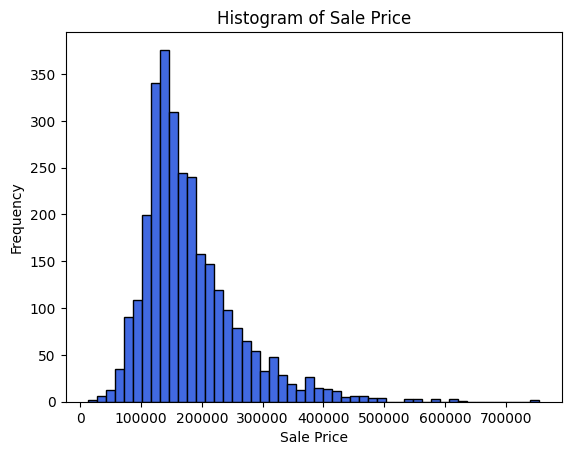

In [37]:
# calculate histogram and draw it with with matplotlib
import matplotlib.pyplot as plt

plt.hist(df.SalePrice, bins=50, edgecolor='black', color='royalblue')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Histogram of Sale Price')
plt.show()

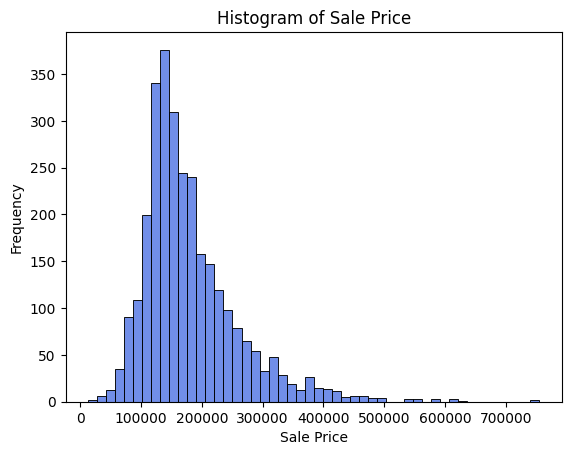

In [38]:
# calculate histogram and draw it with with seaborn
import seaborn as sns

sns.histplot(df.SalePrice, bins=50, color='royalblue')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Histogram of Sale Price')
plt.show()

## KDE (Kernel Density Estimation)

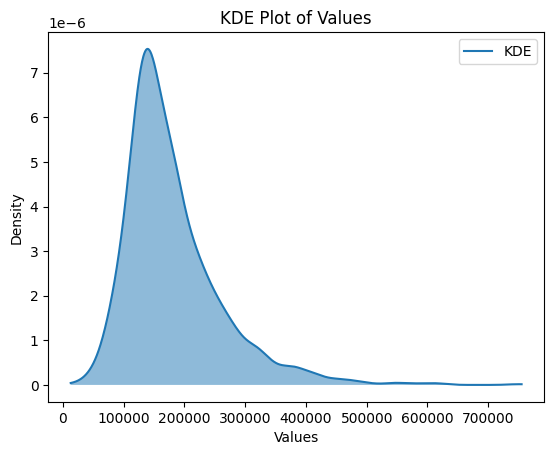

In [39]:
# calculate KDE and draw it with with matplotlib

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the KDE using scipy's gaussian_kde
kde = stats.gaussian_kde(df['SalePrice'])

# Create an array of x values for which to calculate the KDE
x_values = np.linspace(min(df['SalePrice']), max(df['SalePrice']), 1000)

# Evaluate the KDE on the x-values
kde_values = kde(x_values)

# Plot the KDE
plt.plot(x_values, kde_values, label='KDE')

# Customize the plot
plt.title('KDE Plot of Values')
plt.xlabel('Values')
plt.ylabel('Density')

# Optional: fill the area under the KDE curve
plt.fill_between(x_values, kde_values, alpha=0.5)

plt.legend()
plt.show()

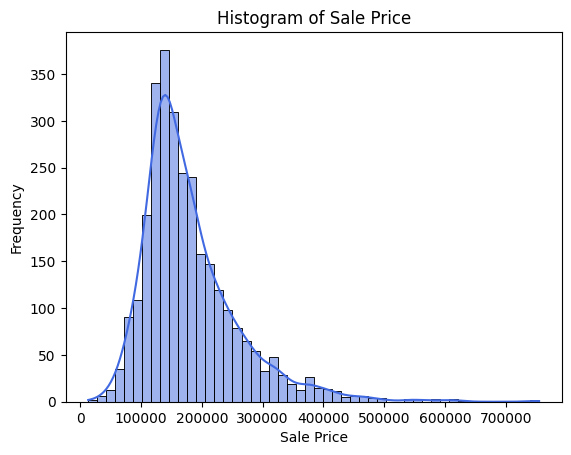

In [40]:
import seaborn as sns

sns.histplot(df.SalePrice, bins=50, color='royalblue' , kde=True)
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Histogram of Sale Price')
plt.show()
#

Text(0.5, 0, 'Sale Price')

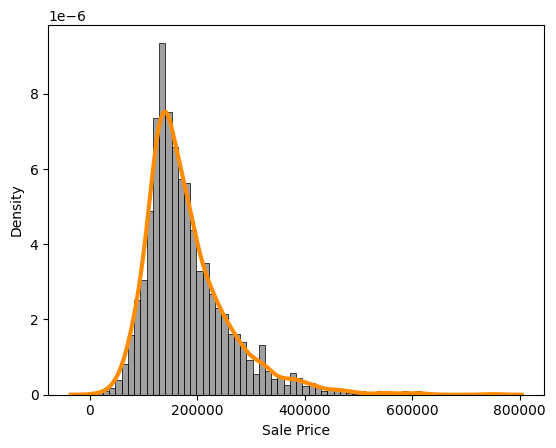

In [41]:
ax = sns.histplot(data=df, x="SalePrice", kde=False, stat='density', color='grey')
# thick line
sns.kdeplot(data=df, x="SalePrice", color='darkorange', ax=ax, linewidth=3)
plt.xlabel('Sale Price')

## ECDF (Empirical Cumulative Distribution Function)

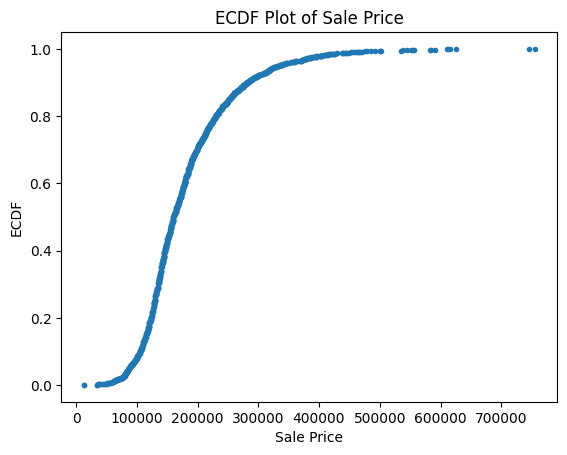

In [42]:
# Calculate with pandas
ecdf = df.SalePrice.value_counts(normalize=True).sort_index().cumsum()
ecdf.plot(marker='.', linestyle='none')
plt.xlabel('Sale Price')
plt.ylabel('ECDF')
plt.title('ECDF Plot of Sale Price')
plt.show()

## Boxplot

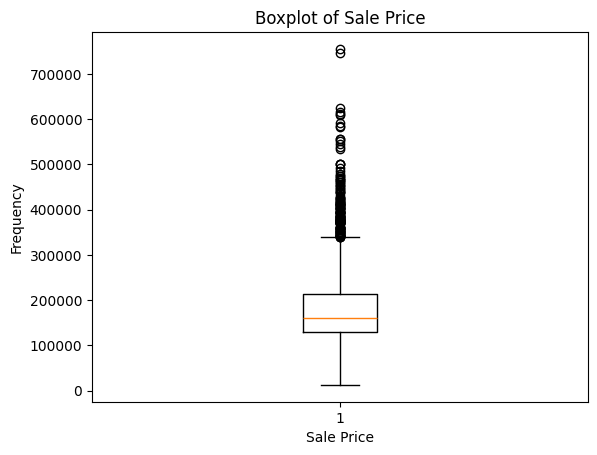

In [43]:
# Calculate boxplot and draw it

plt.boxplot(df.SalePrice)
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.title('Boxplot of Sale Price')
plt.show()

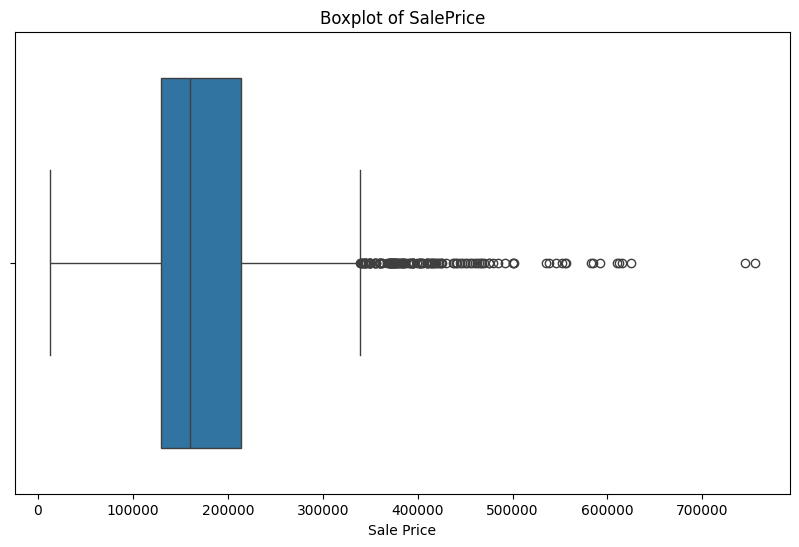

In [44]:
# Boxplot for SalePrice
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['SalePrice'])
plt.title('Boxplot of SalePrice')
plt.xlabel('Sale Price')
plt.show()

In [45]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['SalePrice'] < (Q1 - 1.5 * IQR)) | (df['SalePrice'] > (Q3 + 1.5 * IQR))]
outliers

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
16,527216070,60,RL,47.0,53504,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
18,527258010,20,RL,88.0,11394,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,New,Partial,394432
37,528108120,60,RL,102.0,12858,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2010,New,Partial,376162
39,528120060,20,RL,83.0,10159,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,New,Partial,395192
45,528150070,20,RL,100.0,12919,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,New,Partial,611657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2667,902400110,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,475000
2738,905427030,75,RL,60.0,19800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2006,WD,Normal,415000
2884,911370430,120,RM,41.0,5748,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,2,2006,New,Partial,375000


## Violin Plot

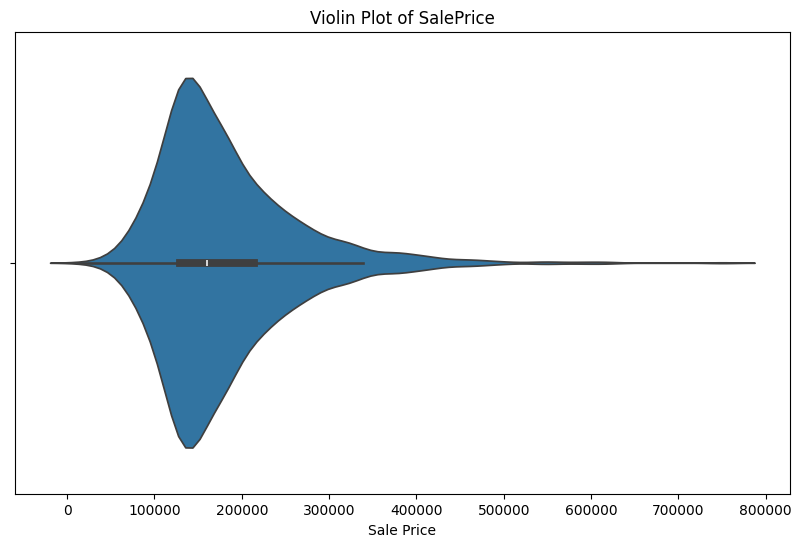

In [46]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['SalePrice'])
plt.title('Violin Plot of SalePrice')
plt.xlabel('Sale Price')
plt.show()

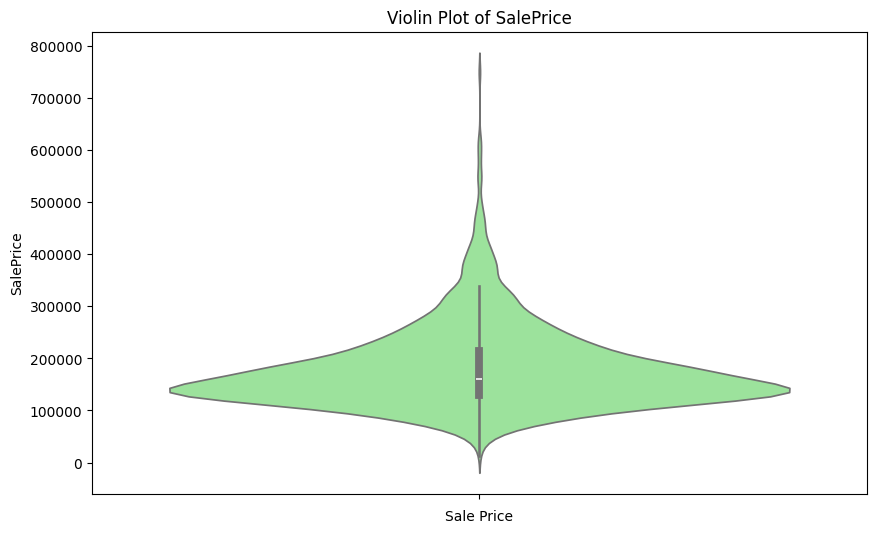

In [47]:
plt.figure(figsize=(10, 6))
sns.violinplot(y=df['SalePrice'], color='lightgreen')
plt.title('Violin Plot of SalePrice')
plt.xlabel('Sale Price')
plt.show()

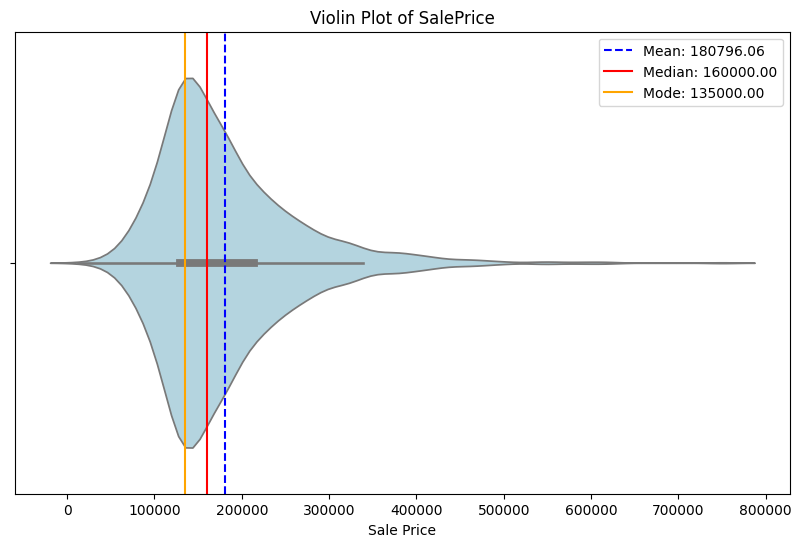

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Calculating statistics
mean = df['SalePrice'].mean()
median = df['SalePrice'].median()
mode = stats.mode(df['SalePrice']).mode

# Creating the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['SalePrice'], color='lightblue')

# Adding lines for mode, median, and mean
plt.axvline(mean, color='blue', linestyle='--', label=f'Mean: {mean:.2f}')
plt.axvline(median, color='red', linestyle='-', label=f'Median: {median:.2f}')
plt.axvline(mode, color='orange', linestyle='-', label=f'Mode: {mode:.2f}')

# Adding titles and labels
plt.title('Violin Plot of SalePrice')
plt.xlabel('Sale Price')
plt.legend()

# Displaying the plot
plt.show()


# **DEMO Bivariate analysis**

---

# Bivariate Analysis

## Scatter plot

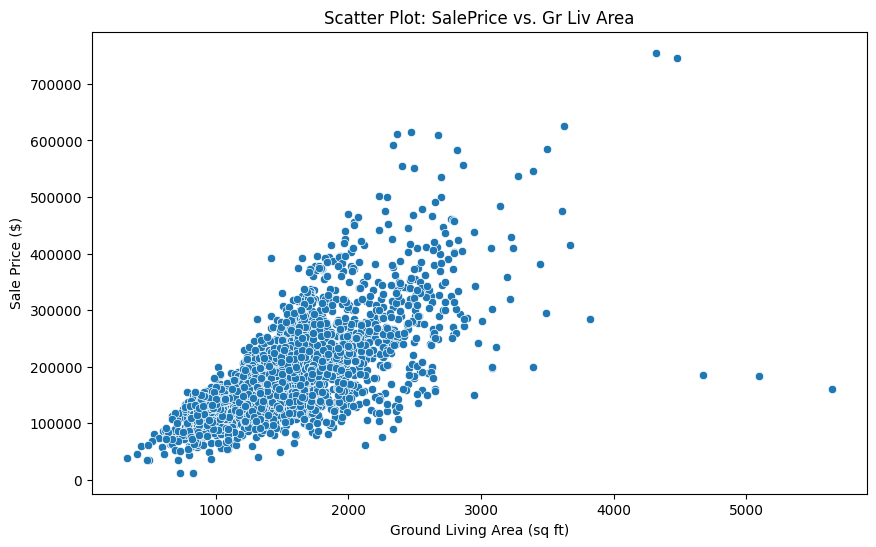

In [49]:
# Scatter plot of SalePrice vs. Gr Liv Area
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df)
plt.title('Scatter Plot: SalePrice vs. Gr Liv Area')
plt.xlabel('Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.show()

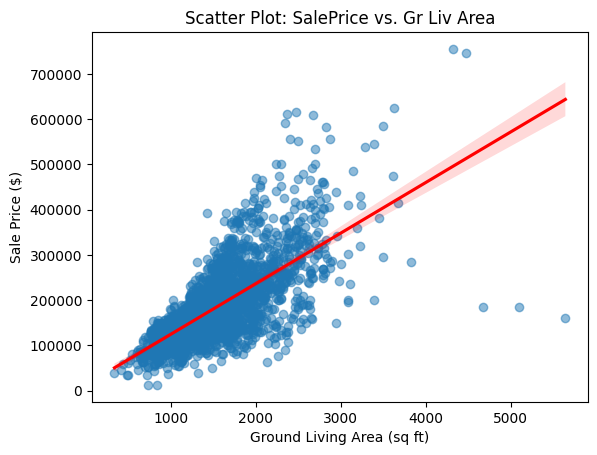

In [50]:
# scatter plot with regression line and correlation coefficient
sns.regplot(x='Gr Liv Area', y='SalePrice', data=df,
            line_kws={'color': 'red'},  # Color of the regression line
            scatter_kws={'alpha': 0.5})  # Transparency of the scatter points (0=transparent, 1=opaque)

plt.title('Scatter Plot: SalePrice vs. Gr Liv Area')
plt.xlabel('Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.show()

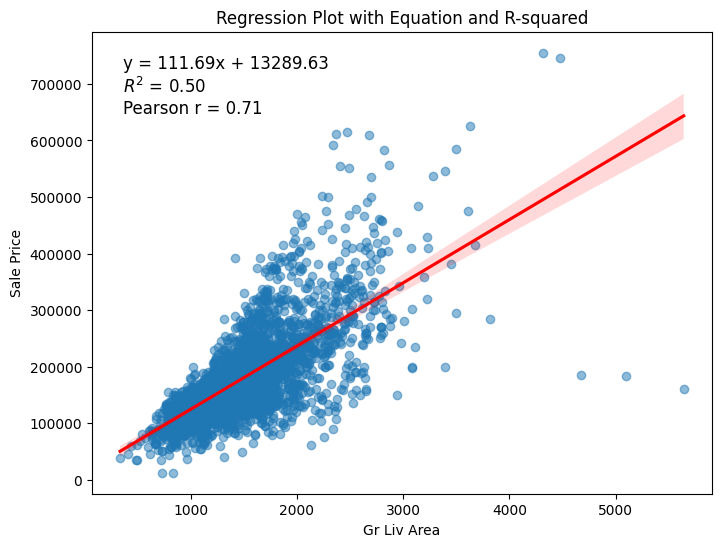

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm


# Performing linear regression using statsmodels
X = sm.add_constant(df['Gr Liv Area'])  # Adds a constant term (intercept) to the predictor
model = sm.OLS(df['SalePrice'], X).fit()  # Fitting the model
intercept, slope = model.params  # Extracting intercept and slope
r_squared = model.rsquared  # Extracting R-squared
# Calculating Pearson correlation coefficient
pearson_corr, _ = stats.pearsonr(df['Gr Liv Area'], df['SalePrice'])  # Pearson correlation coefficient

# Creating the regplot with a custom line color and point transparency
plt.figure(figsize=(8, 6))
sns.regplot(x='Gr Liv Area', y='SalePrice', data=df,
            line_kws={'color': 'red'},  # Color of the regression line
            scatter_kws={'alpha': 0.5})  # Transparency of the scatter points

# Adding the regression equation, R-squared, and Pearson correlation coefficient to the plot
plt.text(0.05, 0.95, f'y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r_squared:.2f}\nPearson r = {pearson_corr:.2f}',
         transform=plt.gca().transAxes,  # Ensure text is positioned relative to plot axes
         fontsize=12, verticalalignment='top')

# Adding titles and labels
plt.title('Regression Plot with Equation and R-squared')
plt.xlabel('Gr Liv Area')
plt.ylabel('Sale Price')

# Displaying the plot
plt.show()

## Correlation Matrix (Heatmap)

In [52]:
correlation_matrix = df[['SalePrice', 'Gr Liv Area', 'Garage Cars', 'Lot Area', 'Overall Qual']].corr()
correlation_matrix['SalePrice'].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
Overall Qual,0.799262
Gr Liv Area,0.706780
Garage Cars,0.647877
Lot Area,0.266549


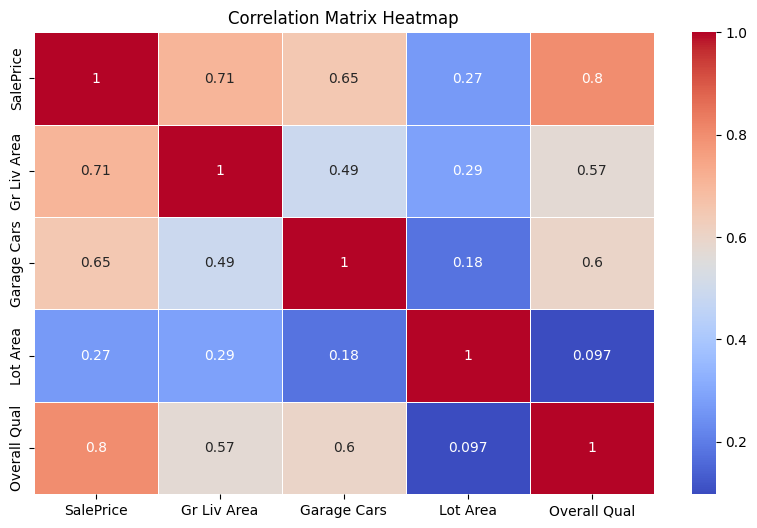

In [53]:
# Correlation matrix using a heatmap
plt.figure(figsize=(10, 6))
corr_matrix = df[['SalePrice', 'Gr Liv Area', 'Garage Cars', 'Lot Area', 'Overall Qual']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

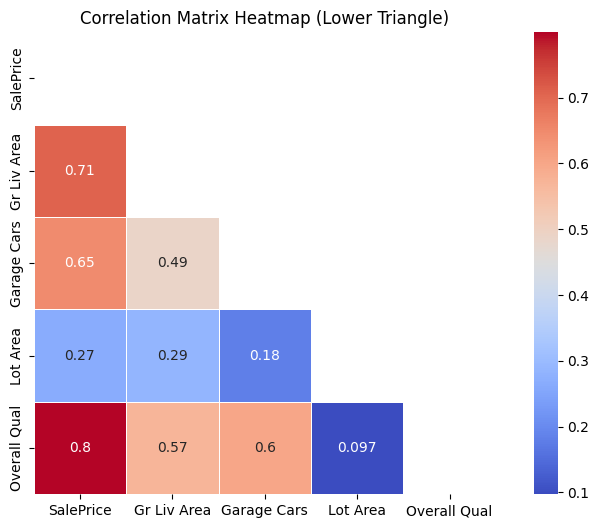

In [54]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the correlation matrix
corr_matrix = df[['SalePrice', 'Gr Liv Area', 'Garage Cars', 'Lot Area', 'Overall Qual']].corr()

# Create a mask for the upper triangle (values not needed)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the figure
plt.figure(figsize=(10, 6))

# Plot the heatmap with the mask
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5, square=True)

# Add title and show the plot
plt.title('Correlation Matrix Heatmap (Lower Triangle)')
plt.show()

## Cross-Tabulation (Contingency Table)

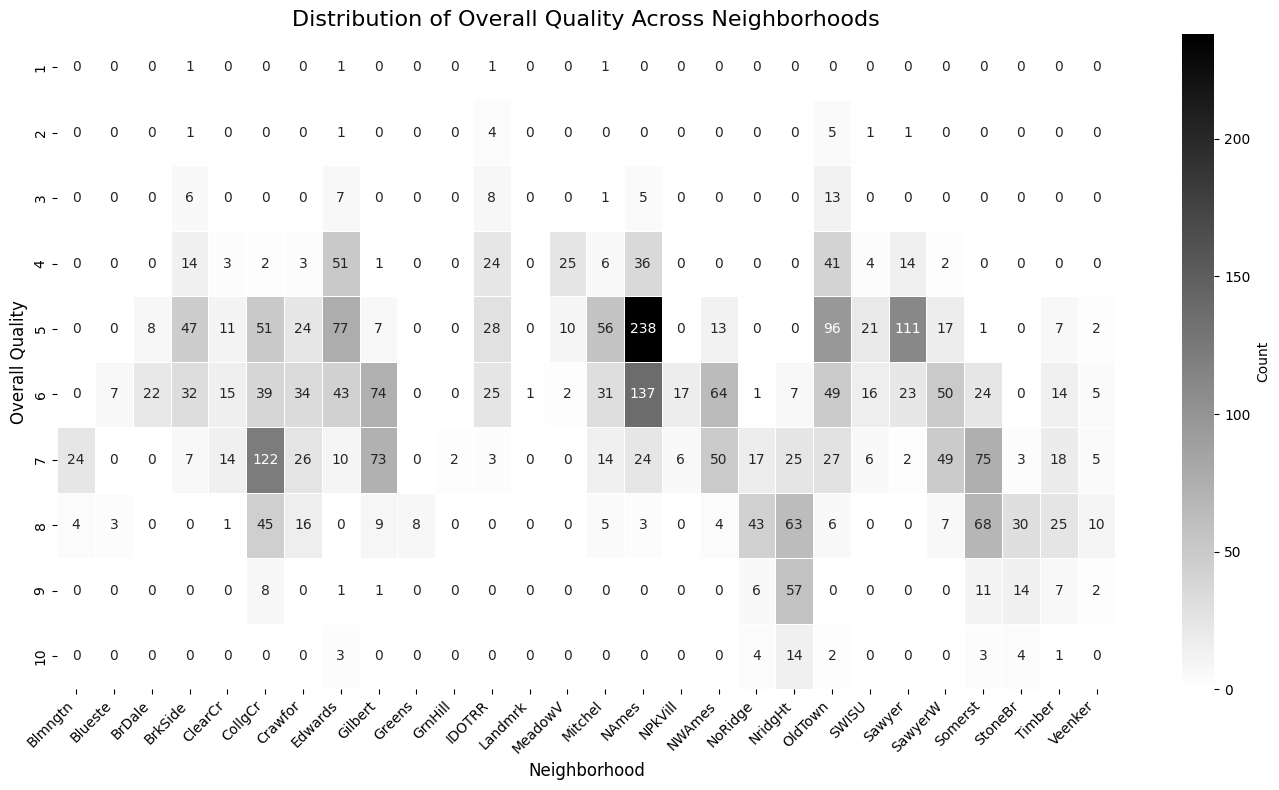

In [55]:
crosstab = pd.crosstab(df['Overall Qual'], df['Neighborhood'])

# Heatmap visualization with improved aesthetics
plt.figure(figsize=(14, 8))

sns.heatmap(crosstab, annot=True, cmap='binary', linewidths=0.5, cbar_kws={'label': 'Count'}, fmt='g')

# Adding more descriptive titles and labels
plt.title('Distribution of Overall Quality Across Neighborhoods', fontsize=16)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('Overall Quality', fontsize=12)

# Rotating the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Adjust layout to avoid clipping of the labels
plt.tight_layout()

# Show the plot
plt.show()

## Joint Plot

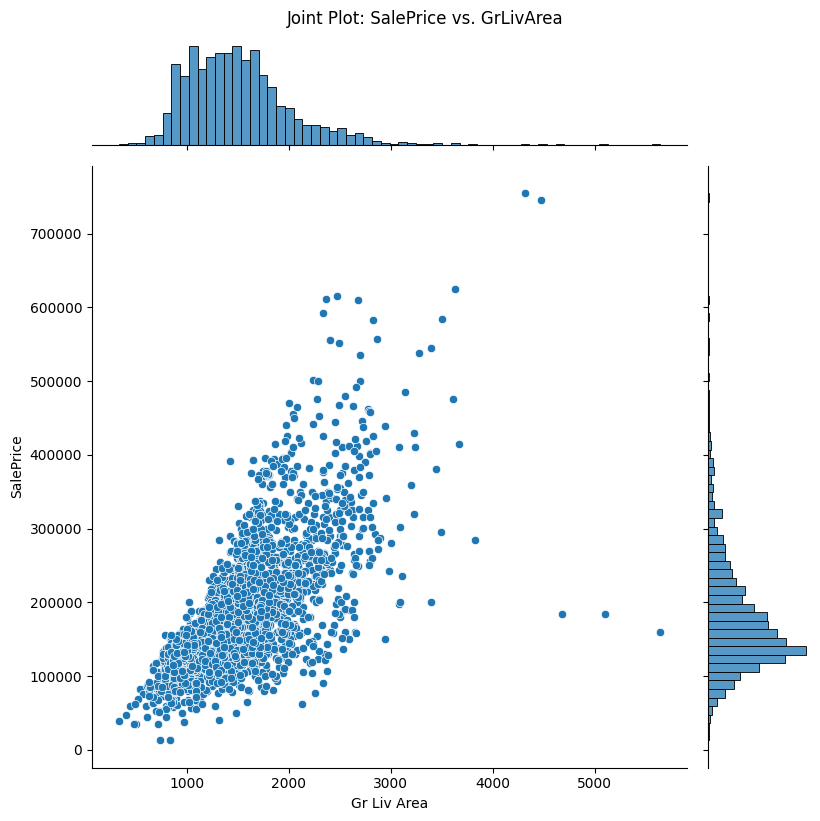

In [56]:
# Joint plot showing SalePrice vs. GrLivArea with histograms
sns.jointplot(x='Gr Liv Area', y='SalePrice', data=df, kind='scatter', height=8)
plt.suptitle('Joint Plot: SalePrice vs. GrLivArea', y=1.02)
plt.show()

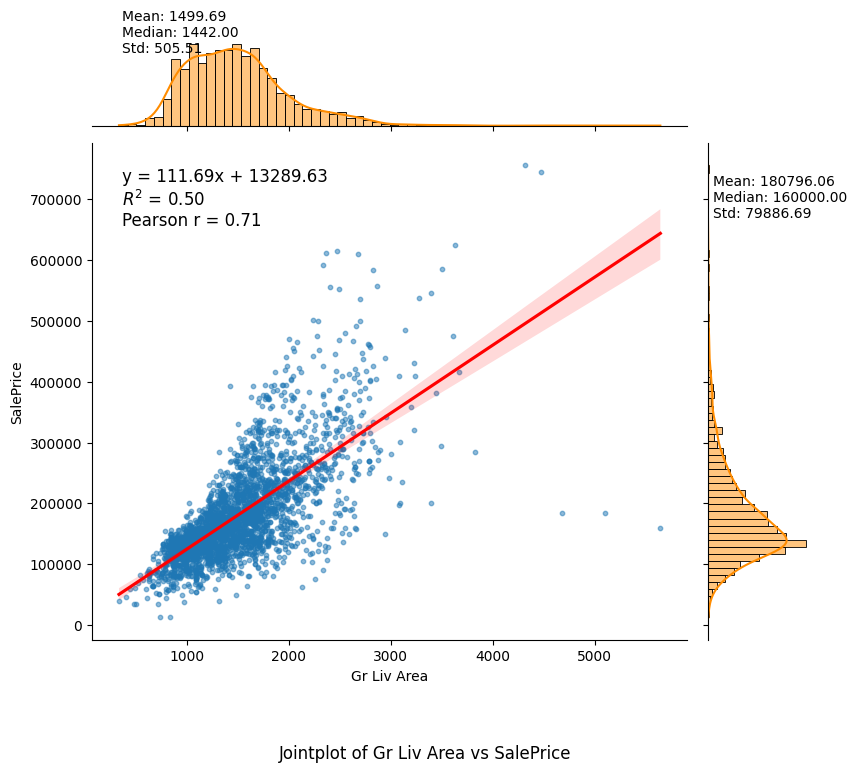

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from scipy import stats


# Performing linear regression using statsmodels
X = sm.add_constant(df['Gr Liv Area'])  # Adds a constant term (intercept) to the predictor
model = sm.OLS(df['SalePrice'], X).fit()  # Fitting the model
intercept, slope = model.params  # Extracting intercept and slope
r_squared = model.rsquared  # Extracting R-squared

# Calculating Pearson correlation coefficient
pearson_corr, _ = stats.pearsonr(df['Gr Liv Area'], df['SalePrice'])  # Pearson correlation coefficient

# Creating the jointplot with a regression line and custom KDE line color
g = sns.jointplot(x='Gr Liv Area', y='SalePrice', data=df, kind='reg', height=8,
                  scatter_kws={'alpha': 0.5, 's':10}, line_kws={'color': 'red'},
                  marginal_kws={'fill': True, 'color': 'darkorange'})  # Change KDE line color

# Adding the regression equation, R-squared, and Pearson correlation coefficient
g.ax_joint.text(0.05, 0.95, f'y = {slope:.2f}x + {intercept:.2f}\n$R^2$ = {r_squared:.2f}\nPearson r = {pearson_corr:.2f}',
                transform=g.ax_joint.transAxes, fontsize=12, verticalalignment='top')

# Calculating statistics for marginal distributions (mean, median, std)
x_mean, x_median, x_std = df['Gr Liv Area'].mean(), df['Gr Liv Area'].median(), df['Gr Liv Area'].std()
y_mean, y_median, y_std = df['SalePrice'].mean(), df['SalePrice'].median(), df['SalePrice'].std()

# Adding statistics for the X-axis (bottom marginal distribution)
g.ax_marg_x.text(0.05, 0.85, f'Mean: {x_mean:.2f}\nMedian: {x_median:.2f}\nStd: {x_std:.2f}',
                 transform=g.ax_marg_x.transAxes, fontsize=10)

# Adding statistics for the Y-axis (left marginal distribution)
g.ax_marg_y.text(0.05, 0.85, f'Mean: {y_mean:.2f}\nMedian: {y_median:.2f}\nStd: {y_std:.2f}',
                 transform=g.ax_marg_y.transAxes, fontsize=10, rotation=0)

# Moving the title to the bottom of the plot
plt.subplots_adjust(top=0.9, bottom=0.15)  # Adjust plot layout to make space for the title at the bottom
plt.suptitle('Jointplot of Gr Liv Area vs SalePrice', y=0.02)

# Displaying the plot
plt.show()

## Hexbin Plot

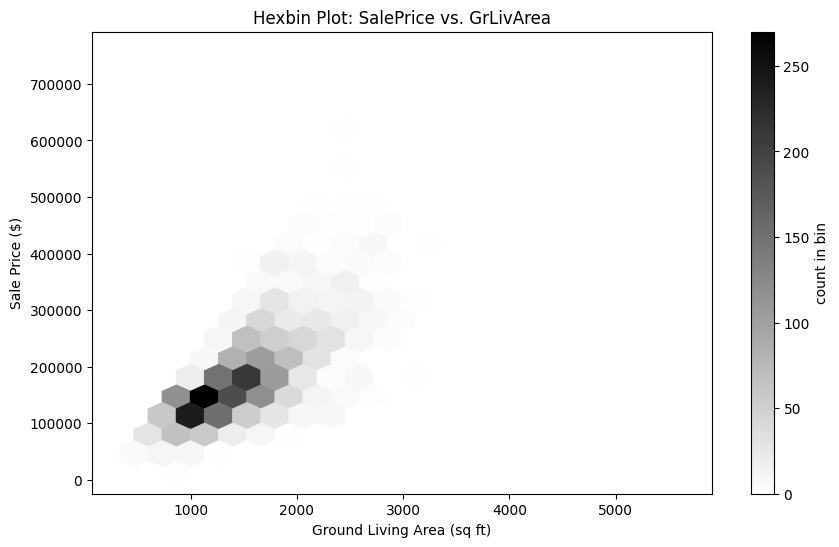

In [58]:
# Hexbin plot for large datasets
plt.figure(figsize=(10, 6))
plt.hexbin(df['Gr Liv Area'], df['SalePrice'], gridsize=20, cmap='binary')
plt.colorbar(label='count in bin')
plt.title('Hexbin Plot: SalePrice vs. GrLivArea')
plt.xlabel('Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.show()

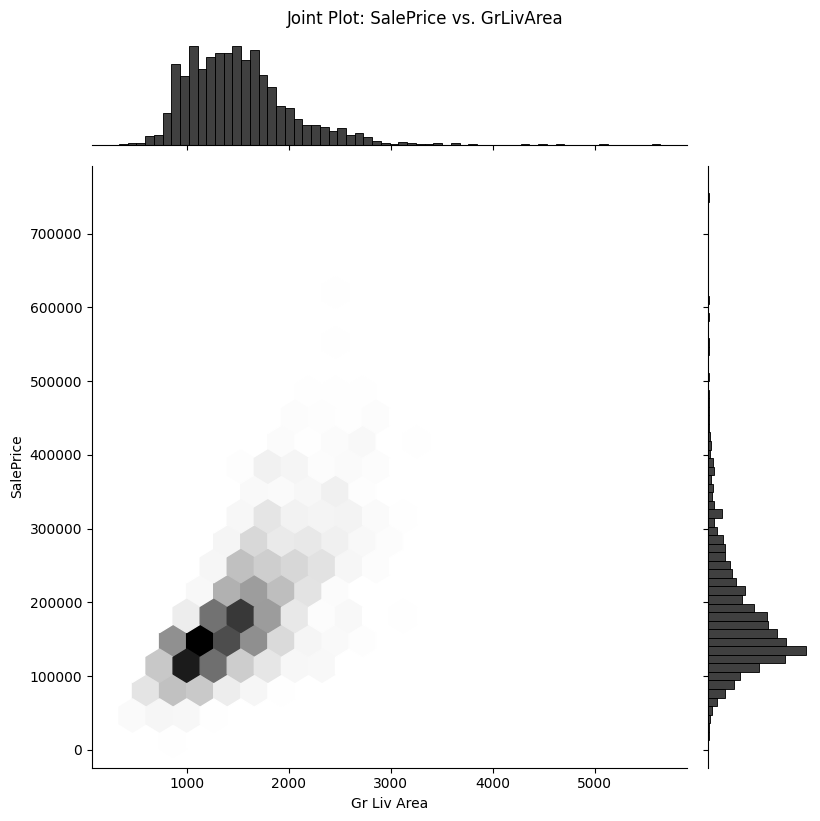

In [59]:
sns.jointplot(x='Gr Liv Area', y='SalePrice', kind="hex", data=df, height=8, joint_kws={'gridsize': 20}, color='black')
plt.suptitle('Joint Plot: SalePrice vs. GrLivArea', y=1.02)
plt.show()

## Bar plot

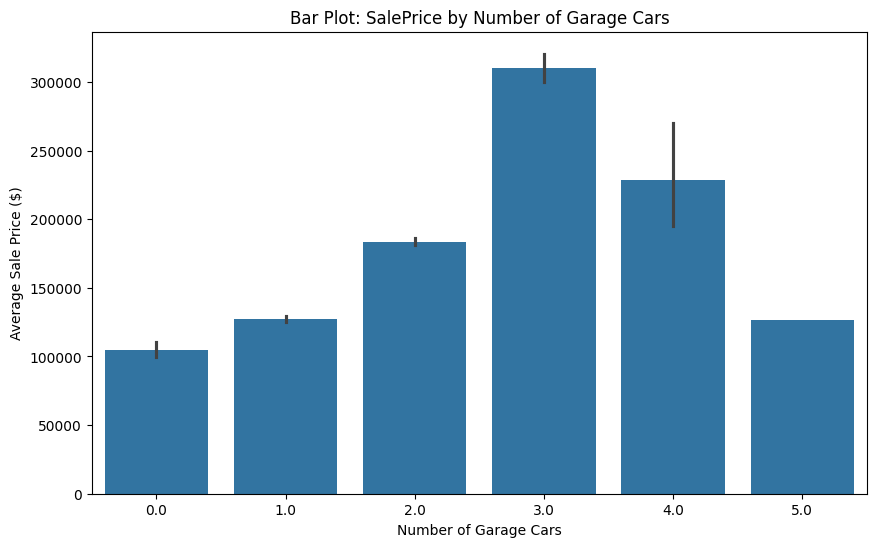

In [60]:
# Bar plot to compare SalePrice by the number of GarageCars
plt.figure(figsize=(10, 6))
sns.barplot(x='Garage Cars', y='SalePrice', data=df)
plt.title('Bar Plot: SalePrice by Number of Garage Cars')
plt.xlabel('Number of Garage Cars')
plt.ylabel('Average Sale Price ($)')
plt.show()

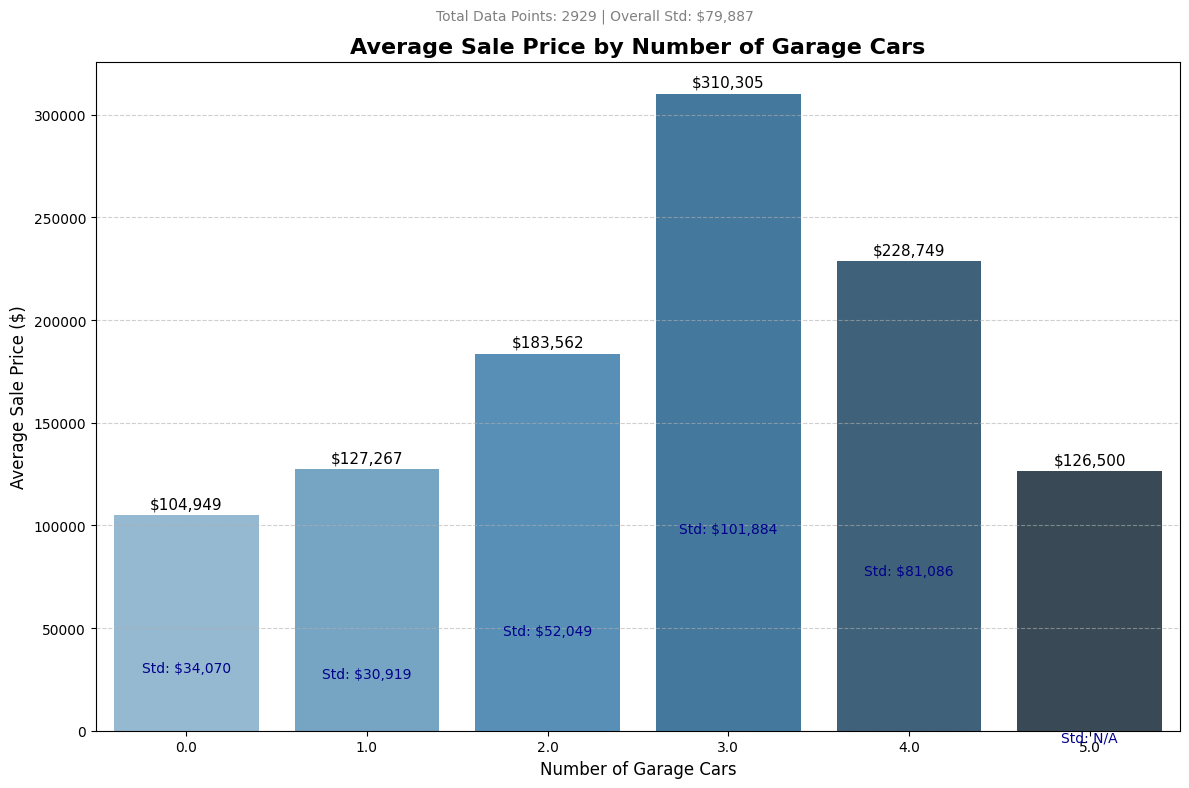

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Calculate statistics (standard deviation) by 'Garage Cars'
stats_df = df.groupby('Garage Cars').agg(std_saleprice=('SalePrice', 'std')).reset_index()

# Setting a color palette
colors = sns.color_palette("Blues_d", n_colors=df['Garage Cars'].nunique())

# Create the bar plot
plt.figure(figsize=(12, 8))
barplot = sns.barplot(x='Garage Cars', y='SalePrice', data=df, errorbar=None, palette=colors, hue='Garage Cars', dodge=False, legend=False)

# Adding exact values on top of the bars (mean of each group)
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'${height:,.0f}',
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='baseline', fontsize=11, color='black',
                     xytext=(0, 5), textcoords='offset points')

# Adding only the standard deviation as annotations
for idx, row in stats_df.iterrows():
    if pd.notna(row["std_saleprice"]):
        # Add standard deviation annotation if it's not NaN
        barplot.annotate(f'Std: ${row["std_saleprice"]:,.0f}',
                         (idx, row["std_saleprice"]),
                         ha='center', va='top', fontsize=10, color='darkblue')
    else:
        # Annotate "N/A" when standard deviation is not defined
        barplot.annotate('Std: N/A',
                         (idx, 0),
                         ha='center', va='top', fontsize=10, color='darkblue')

# Adding gridlines for better readability
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# Customize title and labels
plt.title('Average Sale Price by Number of Garage Cars', fontsize=16, weight='bold')
plt.xlabel('Number of Garage Cars', fontsize=12)
plt.ylabel('Average Sale Price ($)', fontsize=12)

# Adding useful context information below the title
total_cars = df['Garage Cars'].count()
overall_std = df['SalePrice'].std()
plt.suptitle(f'Total Data Points: {total_cars} | Overall Std: ${overall_std:,.0f}',
             fontsize=10, color='gray')

# Display the plot
plt.tight_layout()
plt.show()


<ipython-input-62-4fa4f85dc32a>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  boxplot = sns.boxplot(x='Garage Cars', y='SalePrice', data=df, palette=colors)


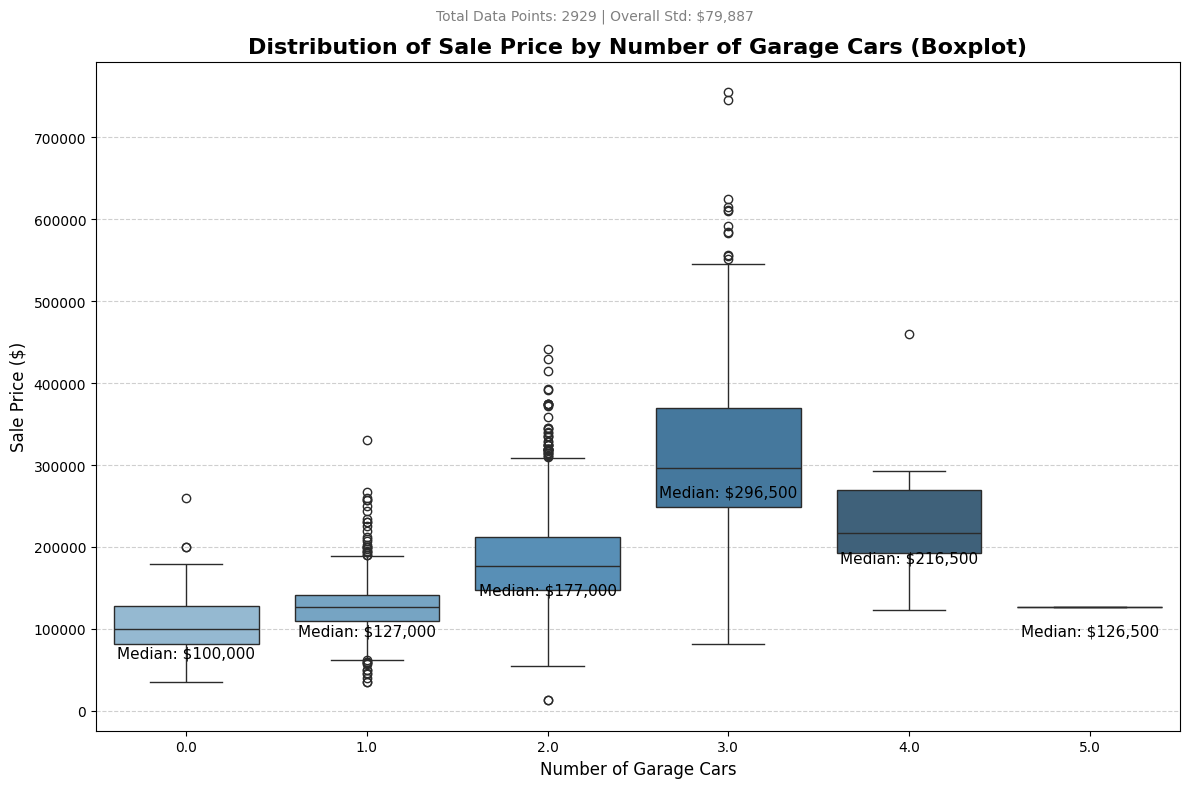

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Setting a color palette
colors = sns.color_palette("Blues_d", n_colors=df['Garage Cars'].nunique())

# Create the boxplot
plt.figure(figsize=(12, 8))
boxplot = sns.boxplot(x='Garage Cars', y='SalePrice', data=df, palette=colors)

# Adding exact values for median of each boxplot
medians = df.groupby('Garage Cars')['SalePrice'].median()
for index, median in enumerate(medians):
    boxplot.annotate(f'Median: ${median:,.0f}',
                     (index, median),
                     ha='center', va='top', fontsize=11, color='black',
                     xytext=(0, -12), textcoords='offset points')

# Adding gridlines for better readability
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# Customize title and labels
plt.title('Distribution of Sale Price by Number of Garage Cars (Boxplot)', fontsize=16, weight='bold')
plt.xlabel('Number of Garage Cars', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)

# Adding useful context information below the title
total_cars = df['Garage Cars'].count()
overall_std = df['SalePrice'].std()
plt.suptitle(f'Total Data Points: {total_cars} | Overall Std: ${overall_std:,.0f}',
             fontsize=10, color='gray')

# Display the plot
plt.tight_layout()
plt.show()


In [63]:
df['Garage Cars'].value_counts()

,count
Garage Cars,
2.0,1603
1.0,778
3.0,374
0.0,157
4.0,16
5.0,1


In [64]:
# calculate mean and std by groupby
df[['SalePrice', 'Garage Cars']].groupby('Garage Cars').agg(['mean', 'std'])

SalePrice               
                      mean            std
Garage Cars                              
0.0          104949.254777   34069.812774
1.0          127267.422879   30919.144428
2.0          183562.102932   52049.019349
3.0          310304.622995  101883.797291
4.0          228748.687500   81085.969158
5.0          126500.000000            NaN

In [65]:
# Group by 'Neighborhood' and calculate the mean and median sale price
neighborhood_stats = df.groupby('Neighborhood')['SalePrice'].agg(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False)
neighborhood_stats

,mean,median,std,count
Neighborhood,,,,
NoRidge,330319.126761,302000.0,101444.662927,71
StoneBr,324229.196078,319000.0,119273.020694,51
NridgHt,322018.265060,317750.0,95932.354274,166
GrnHill,280000.000000,280000.0,70710.678119,2
Veenker,248314.583333,250250.0,65474.949540,24
Timber,246599.541667,232106.5,69326.471547,72
Somerst,229707.324176,225500.0,57437.392588,182
ClearCr,208662.090909,197500.0,51280.213463,44
Crawfor,207550.834951,200624.0,65230.183286,103


In [66]:
pivot = pd.pivot_table(df, values='SalePrice', index=['Neighborhood'], aggfunc=[np.mean, np.median, np.std])
pivot

<ipython-input-66-31bc94f1a963>:1: FutureWarning: The provided callable <function mean at 0x7cf4d6cf6b60> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot = pd.pivot_table(df, values='SalePrice', index=['Neighborhood'], aggfunc=[np.mean, np.median, np.std])
<ipython-input-66-31bc94f1a963>:1: FutureWarning: The provided callable <function median at 0x7cf4d67b71a0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  pivot = pd.pivot_table(df, values='SalePrice', index=['Neighborhood'], aggfunc=[np.mean, np.median, np.std])
<ipython-input-66-31bc94f1a963>:1: FutureWarning: The provided callable <function std at 0x7cf4d6cf6ca0> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be use

,mean,median,std
,SalePrice,SalePrice,SalePrice
Neighborhood,,,
Blmngtn,196661.678571,191500.0,29317.511457
Blueste,143590.000000,130500.0,30158.523763
BrDale,105608.333333,106000.0,12144.773839
BrkSide,124756.250000,126750.0,35740.935575
ClearCr,208662.090909,197500.0,51280.213463
CollgCr,201803.434457,200000.0,54187.843749
Crawfor,207550.834951,200624.0,65230.183286
Edwards,130843.381443,125000.0,48030.405046


## Pair Plot

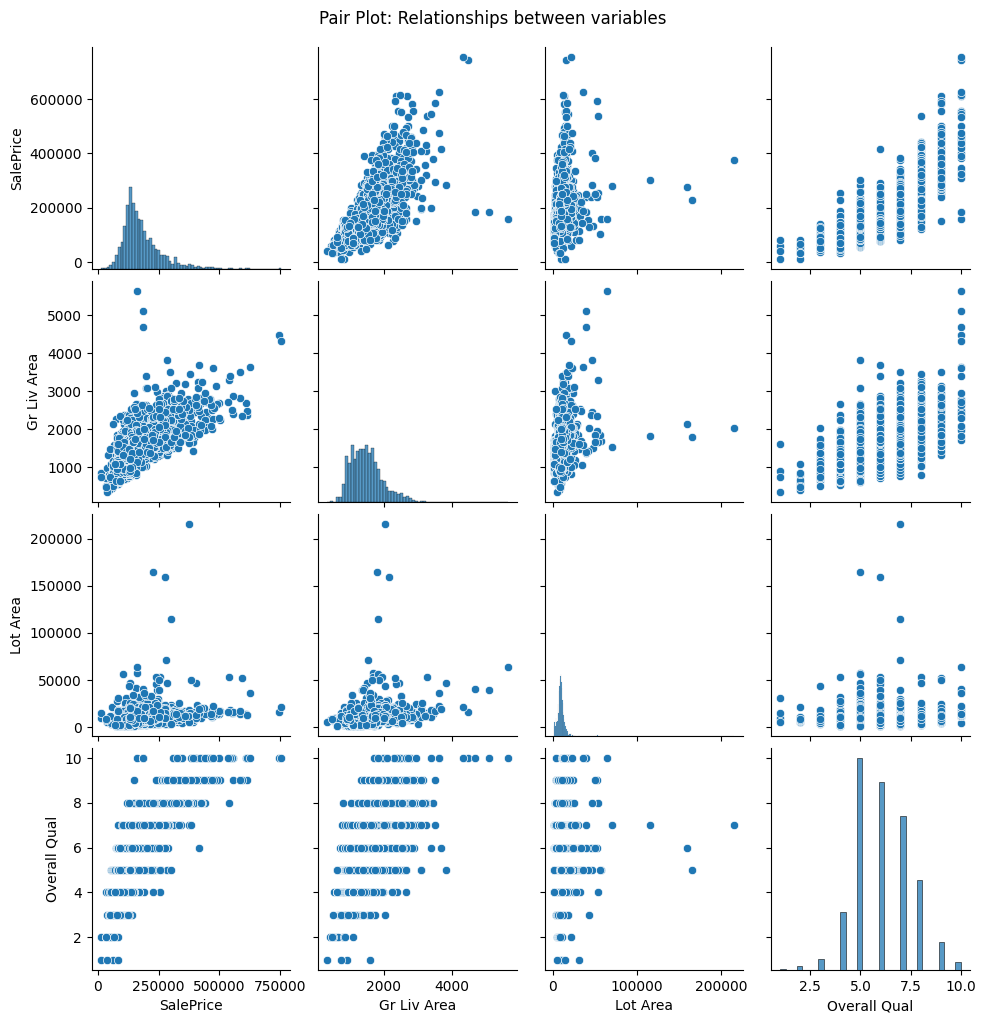

In [67]:
# Pair plot showing relationships between multiple variables
sns.pairplot(df[['SalePrice', 'Gr Liv Area', 'Lot Area', 'Overall Qual']])
plt.suptitle('Pair Plot: Relationships between variables', y=1.02)
plt.show()

# **DEMO Multivariate analysis**


---

# Multivariate analysis

## Categorical and Numeric Statistics Together

In [68]:
df.groupby('Garage Cars').agg({
    'SalePrice': ['mean', 'median', 'std', 'count'],
    'Lot Area': ['mean', 'median'],
})

SalePrice                                     Lot Area  \
                      mean    median            std count          mean   
Garage Cars                                                               
0.0          104949.254777  100000.0   34069.812774   157   7714.560510   
1.0          127267.422879  127000.0   30919.144428   778   8551.624679   
2.0          183562.102932  177000.0   52049.019349  1603  10479.137867   
3.0          310304.622995  296500.0  101883.797291   374  12934.764706   
4.0          228748.687500  216500.0   81085.969158    16  13481.625000   
5.0          126500.000000  126500.0            NaN     1   8635.000000   

                      
              median  
Garage Cars           
0.0           7920.0  
1.0           8400.0  
2.0           9500.0  
3.0          11840.0  
4.0          11239.5  
5.0           8635.0

## 3D Scatter Plot

In [69]:
import pandas as pd
import plotly.express as px

# Load your dataset (Replace this with your actual dataset loading code)
# df = pd.read_csv('your_dataset.csv')  # Example to load dataset from a CSV

# 3D Scatter plot using Plotly for your dataset (Assuming columns 'GrLivArea', 'LotArea', and 'SalePrice')
fig = px.scatter_3d(df, x='Gr Liv Area', y='Lot Area', z='SalePrice',
                    color='Overall Qual',  # Color the points based on 'OverallQual'
                    title='3D Scatter Plot: GrLivArea, LotArea, and SalePrice',
                    labels={'GrLivArea':'Ground Living Area', 'LotArea':'Lot Area', 'SalePrice':'Sale Price'})

# Set marker size smaller
fig.update_traces(marker=dict(size=3))  # Adjust 'size' for smaller markers

# Show the plot
fig.show()


## Violin plot for multivariate case

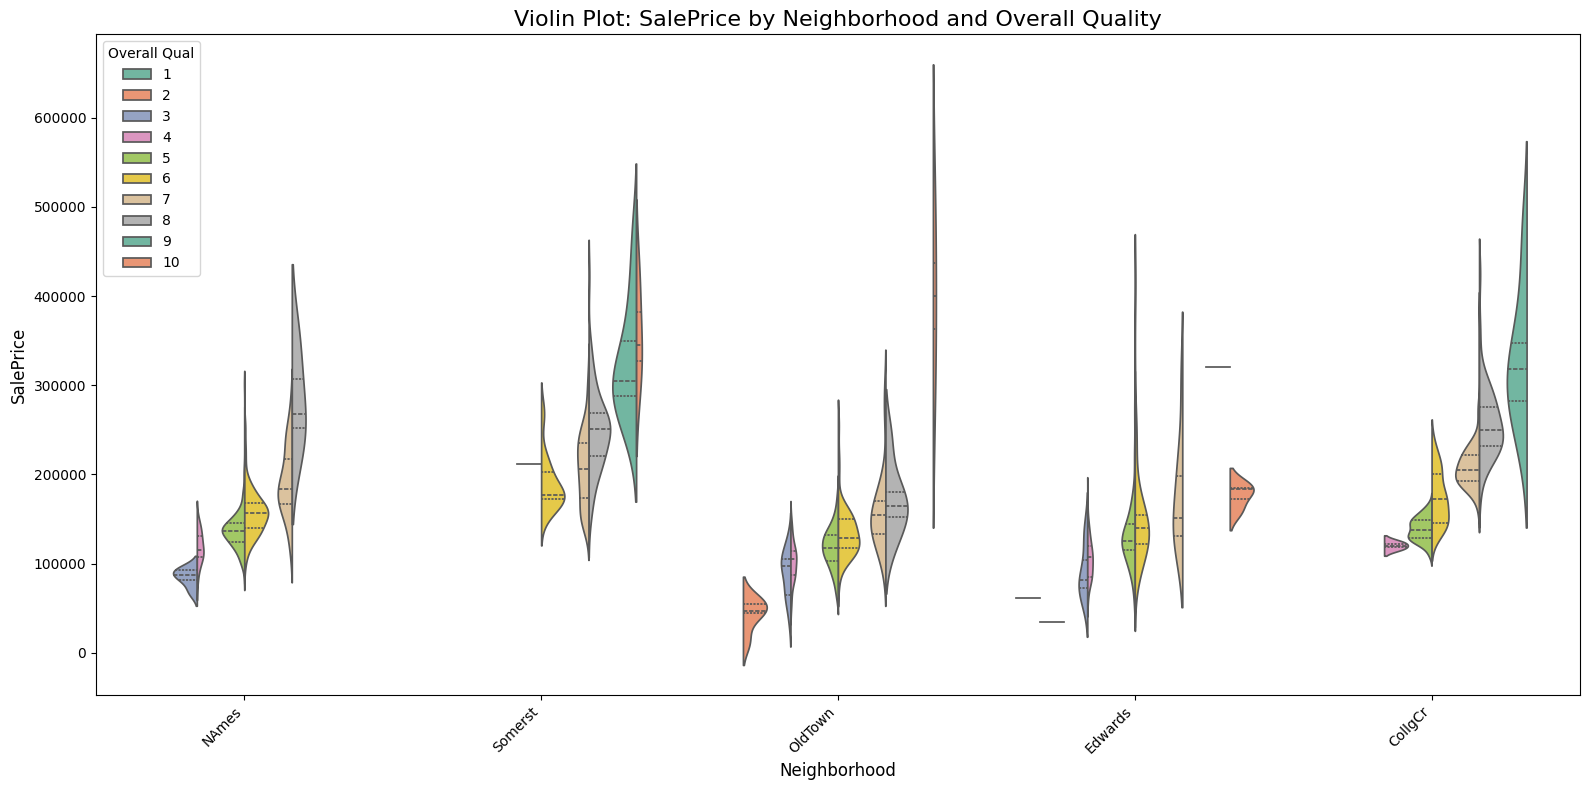

In [70]:
# Assuming 'Neighborhood' and 'OverallQual' are available categorical variables
# Limit the number of Neighborhoods by selecting the top 5 most frequent ones
top_bldgtypes = df['Neighborhood'].value_counts().index[:5]

# Filter the dataset to include only the top 5 Neighborhoods
df_filtered = df[df['Neighborhood'].isin(top_bldgtypes)]

# Violin plot for SalePrice grouped by the top 5 Neighborhood categories and OverallQual
plt.figure(figsize=(16, 8))

# Create the violin plot with hue for multivariate analysis
sns.violinplot(x='Neighborhood', y='SalePrice', hue='Overall Qual', data=df_filtered, split=True, inner='quart', palette='Set2')

# Add titles and labels
plt.title('Violin Plot: SalePrice by Neighborhood and Overall Quality', fontsize=16)
plt.xlabel('Neighborhood', fontsize=12)
plt.ylabel('SalePrice', fontsize=12)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.tight_layout()
plt.show()